In [1]:
import polars as pl

from deq.plot import line_plot, grouped_bars
from spells import summon, ColSpec, ColType
from spells.config import all_sets

In [57]:
ext={
    "has_splash": ColSpec(col_type=ColType.GROUP_BY,
                          expr=pl.when(pl.col("splash_colors").is_null()).then(False).otherwise(True)),
    "deck_lands_gb": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_lands_{name}") for name in names])),
     "deck_spells_hz": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_spells_{name}") for name in names])),
     "deck_mv_hz": ColSpec(col_type=ColType.GROUP_BY, expr=lambda names: pl.sum_horizontal([pl.col(f"deck_mana_value_{name}") for name in names])),
     "deck_mv_ratio": ColSpec(col_type=ColType.GROUP_BY, expr=pl.col('deck_mv_hz') / pl.col('deck_spells_hz')),
     "deck_mv_class": ColSpec(col_type=ColType.GROUP_BY, expr=(pl.col("deck_mv_ratio") * 5).round() / 5)}


In [80]:
df = summon(all_sets, ["game_wr", "num_games"],
            group_by=["deck_lands_gb", "deck_mv_class"],
            extensions=ext, 
            filter_spec={'$and':[
                {'num_colors': 2},
                {"has_splash":False},
                {"player_cohort": "Top"}
            ]})

In [81]:
pivot = df.filter(  
    pl.col('num_games') > 5000).pivot(   
    on="deck_lands_gb", 
    index="deck_mv_class", 
    values="game_wr").sort(
    "deck_mv_class").rename(
    {'deck_mv_class': 'Deck Average Mana Value'})

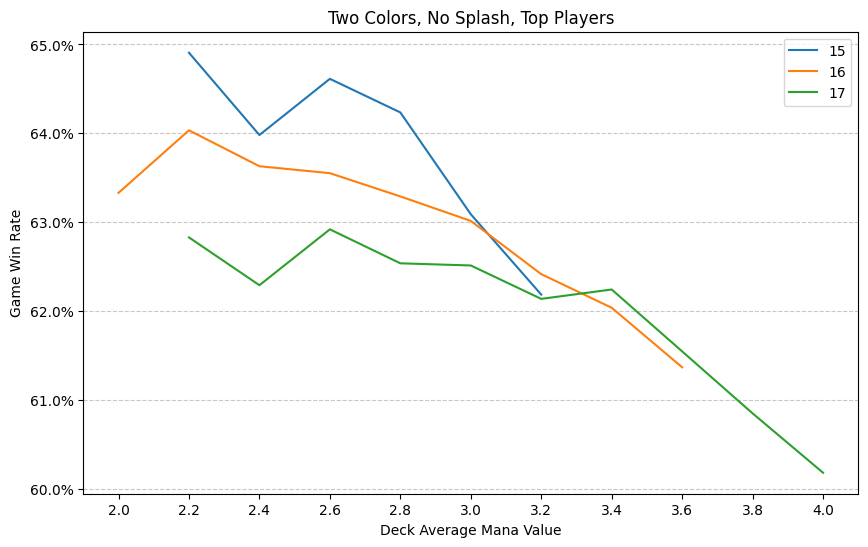

In [83]:
line_plot(
    pivot, 
    title="Two Colors, No Splash, Top Players",
    is_pct=True,
    y_label="Game Win Rate"
)


In [2]:
wr_df=summon(
    ["DFT", "FDN", "PIO", 
     "BLB", "OTJ", "DSK", "MH3",
    "MKM", "KTK", "LCI", "LTR", "WOE"
    ], ["game_wr"], group_by=["game_hour"],
      filter_spec={"player_cohort":"Top"} )



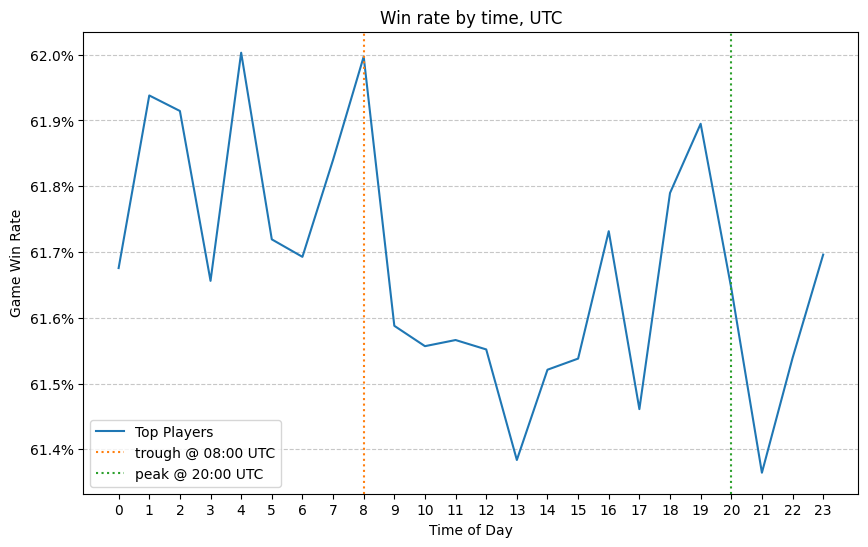

In [6]:
ax = line_plot(wr_df.rename({'game_wr': 'Top Players', 'game_hour': 'Time of Day'}), 
          title="Win rate by time, UTC",
          is_pct=True, 
          y_label="Game Win Rate",
          return_ax=True
    )


ax.axvline(x =8, color="#ff7f0e", linestyle=":", label="trough @ 08:00 UTC")
ax.axvline(x = 20, color="#2ca02c", linestyle=":", label="peak @ 20:00 UTC")
ax.legend()



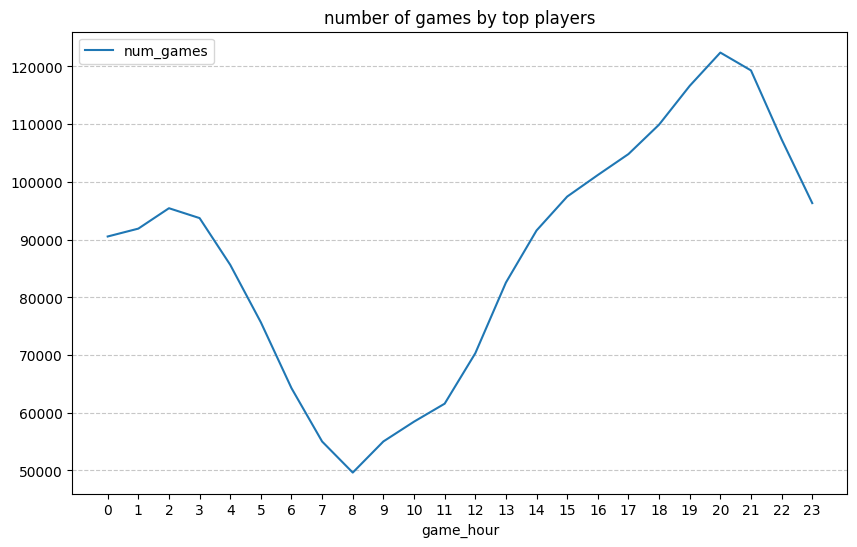

In [7]:
df=summon(
    ["DFT", "FDN", "PIO", 
     "BLB", "OTJ", "DSK", "MH3",
    "MKM", "KTK", "LCI", "LTR", "WOE"
    ], ["num_games"], group_by=["game_hour"],
      filter_spec={"player_cohort":"Top"} )
line_plot(df, title="number of games by top players")


In [49]:
summon(all_sets, ["deck_mana_value_avg"], group_by=[], filter_spec={'player_cohort':'Top'})

deck_mana_value_avg
f64
2.912826
